# Phase 5 — Demand Forecasting

**Project:** Supply Chain Demand Forecasting & Inventory Optimization  
**Phase:** 5 — Demand Forecasting  
**Primary horizon:** 30 days  
**Forecast grain:** `Date × Store ID × Product ID`  
**Final test period:** 2024-01-01 to 2024-01-30

### Source-of-truth reconciliation
`PROJECT_MASTER.md` is the project-level specification. It currently still records the project as being in dataset selection, while this Phase 5 rebuild is explicitly being performed against the supplied and already-audited `sales_data.csv`. This notebook therefore follows the Phase 5 requirements supplied for this rebuild and does **not** silently rewrite `PROJECT_MASTER.md`.

### Methodological principle
The final January 2024 Demand values remain untouched until forecasts are fully generated and model decisions are frozen. Validation uses exactly **2023-12-01 to 2023-12-31** for every candidate model. All multi-step ML forecasts are recursive so that actual future Demand never enters January lag or rolling features.


## 5.1 Forecasting Objective and Horizon

**Objective:** Forecast daily `Demand` for each Store × Product series.

**Primary horizon:** 30 days.

**Secondary horizons:** 7, 60, and 90 days are not used in the primary model-selection workflow. They may be added later only if a business requirement justifies them.

**Chronological design**

| Split | Period | Role |
|---|---|---|
| Training | 2022-01-01 → 2023-11-30 | Fit candidate models |
| Validation | 2023-12-01 → 2023-12-31 | Model comparison and selection |
| Final test | 2024-01-01 → 2024-01-30 | Untouched final evaluation |

Metrics: **MAE, RMSE, sMAPE**.

Model selection is based only on validation results. January 2024 actuals are joined only after the final forecasts have been generated.


In [3]:
# 5.2 Imports and reproducibility
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

RANDOM_STATE = 42
PRIMARY_HORIZON = 30

TRAIN_END = pd.Timestamp("2023-11-30")
VAL_START = pd.Timestamp("2023-12-01")
VAL_END = pd.Timestamp("2023-12-31")

TEST_START = pd.Timestamp("2024-01-01")
TEST_END = pd.Timestamp("2024-01-30")

# Google Drive dataset path
DATA_PATH = Path(
    "/content/drive/MyDrive/SupplychainManagement/sales_data.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Make sure Google Drive is mounted and sales_data.csv exists "
        "inside MyDrive/SupplychainManagement/."
    )

# Save final forecasts in the same project folder
OUTPUT_PATH = DATA_PATH.parent / "final_demand_forecasts.csv"

print(f"Data source: {DATA_PATH}")
print(f"Output path: {OUTPUT_PATH}")

Data source: /content/drive/MyDrive/SupplychainManagement/sales_data.csv
Output path: /content/drive/MyDrive/SupplychainManagement/final_demand_forecasts.csv


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 5.2 Forecasting Dataset Construction

The source file is loaded without silently repairing or deleting observations. The checks below verify the established grain and temporal structure before any modeling occurs.

The natural key is `Date + Store ID + Product ID`. Each Store × Product series is expected to contain exactly 760 consecutive daily observations.


In [5]:
# Load source data and standardize only the date dtype
sales_raw = pd.read_csv(DATA_PATH)
sales_raw["Date"] = pd.to_datetime(sales_raw["Date"], errors="raise")

expected_columns = {
    "Date", "Store ID", "Product ID", "Category", "Region",
    "Inventory Level", "Units Sold", "Units Ordered", "Price",
    "Discount", "Weather Condition", "Promotion", "Competitor Pricing",
    "Seasonality", "Epidemic", "Demand"
}
missing_columns = expected_columns.difference(sales_raw.columns)
if missing_columns:
    raise ValueError(f"Required columns missing from source data: {sorted(missing_columns)}")

forecasting_df = sales_raw.copy()

print("Rows:", len(forecasting_df))
print("Columns:", len(forecasting_df.columns))
print("Date range:", forecasting_df["Date"].min().date(), "to", forecasting_df["Date"].max().date())
print("Stores:", forecasting_df["Store ID"].nunique())
print("Products:", forecasting_df["Product ID"].nunique())
print("Store × Product series:", forecasting_df[["Store ID", "Product ID"]].drop_duplicates().shape[0])


Rows: 76000
Columns: 16
Date range: 2022-01-01 to 2024-01-30
Stores: 5
Products: 20
Store × Product series: 100


In [6]:
# Structural and data-quality validation
core_columns = ["Date", "Store ID", "Product ID", "Demand"]

duplicate_keys = forecasting_df.duplicated(
    subset=["Date", "Store ID", "Product ID"]
).sum()

missing_core = forecasting_df[core_columns].isna().sum()

series_sizes = forecasting_df.groupby(
    ["Store ID", "Product ID"], sort=False
).size()

def series_is_continuous(group):
    dates = group["Date"].sort_values()
    return (
        dates.nunique() == len(dates)
        and dates.diff().dropna().eq(pd.Timedelta(days=1)).all()
    )

continuity_ok = forecasting_df.groupby(
    ["Store ID", "Product ID"], sort=False
).apply(series_is_continuous)

print("Duplicate natural keys:", duplicate_keys)
print("Missing core values:")
print(missing_core)
print("Series-size summary:")
print(series_sizes.describe())
print("All series have 760 rows:", bool(series_sizes.eq(760).all()))
print("All series are daily-continuous:", bool(continuity_ok.all()))

assert len(forecasting_df) == 76000
assert forecasting_df["Date"].min() == pd.Timestamp("2022-01-01")
assert forecasting_df["Date"].max() == pd.Timestamp("2024-01-30")
assert forecasting_df["Store ID"].nunique() == 5
assert forecasting_df["Product ID"].nunique() == 20
assert series_sizes.size == 100
assert series_sizes.eq(760).all()
assert duplicate_keys == 0
assert missing_core.sum() == 0
assert continuity_ok.all()


Duplicate natural keys: 0
Missing core values:
Date          0
Store ID      0
Product ID    0
Demand        0
dtype: int64
Series-size summary:
count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
dtype: float64
All series have 760 rows: True
All series are daily-continuous: True


/tmp/ipykernel_4661/3099351635.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(series_is_continuous)


### 5.3 Target Definition

`Demand` is the target because the forecasting objective is future product demand. `Units Sold` is not substituted for Demand: it is highly correlated with Demand and can encode information that is only known after demand has materialized or been fulfilled.

No same-timestamp `Demand` value is used as a predictor. Historical Demand enters ML models only through lagged/strictly past rolling features.


In [7]:
# Target validation
target_summary = forecasting_df["Demand"].describe().to_frame("Demand")
target_summary.loc["missing"] = forecasting_df["Demand"].isna().sum()
target_summary


,Demand
count,76000.000000
mean,104.317158
std,46.964801
min,4.000000
25%,71.000000
50%,100.000000
75%,133.000000
max,430.000000
missing,0.000000


## 5.4 Leakage Audit

The forecasting model intentionally excludes operational variables whose values may reflect realized demand or downstream decisions.

| Variable family | Classification | Main-model treatment |
|---|---|---|
| Date, Store ID, Product ID | Structural identifiers | Used for indexing/grouping; Store/Product also encode persistent series differences |
| Category, Region | Safe/static | Used as static categorical features |
| Historical Demand lags/rolling features | Safe when shifted | Used |
| Calendar variables | Safe | Used because future calendar dates are known |
| Price, Discount, Promotion, Weather Condition, Competitor Pricing, Epidemic | Conditional | Excluded from the primary model because future availability is not established by the source |
| Units Sold | Leakage-prone | Excluded |
| Inventory Level | Leakage-prone | Excluded |
| Units Ordered | Leakage-prone | Excluded |

The conditional variables are not automatically treated as safe merely because they correlate with Demand. A future forecast may use them only if a real forecast-time process guarantees their values are known for the whole horizon.


In [8]:
# Explicit leakage audit table
leakage_audit = pd.DataFrame([
    ["Date", "Safe / potentially usable", "Known calendar information; used for calendar features"],
    ["Store ID", "Structural identifier", "Defines forecast series; used as static categorical feature"],
    ["Product ID", "Structural identifier", "Defines forecast series; used as static categorical feature"],
    ["Category", "Safe / potentially usable", "Static product attribute; used"],
    ["Region", "Safe / potentially usable", "Static store attribute; used"],
    ["Demand", "Target / historical only", "Never used at the same timestamp; only prior values enter lag/rolling features"],
    ["Units Sold", "Leakage-prone", "Excluded; highly correlated with Demand and potentially downstream of realized demand"],
    ["Inventory Level", "Leakage-prone", "Excluded; operational state can reflect prior/current demand and replenishment decisions"],
    ["Units Ordered", "Leakage-prone", "Excluded; replenishment decision variable can encode information unavailable to a pure demand forecast"],
    ["Price", "Conditional", "Excluded from primary model because future availability is not established"],
    ["Discount", "Conditional", "Excluded from primary model because future availability is not established"],
    ["Promotion", "Conditional", "Excluded from primary model because future availability is not established"],
    ["Weather Condition", "Conditional", "Excluded from primary model because future values are not guaranteed known"],
    ["Competitor Pricing", "Conditional", "Excluded from primary model because future values are not guaranteed known"],
    ["Epidemic", "Conditional", "Excluded from primary model because future values are not guaranteed known"],
    ["Seasonality", "Conditional / calendar-derived", "Not required because Month and cyclical calendar features are generated directly from Date"],
], columns=["Variable", "Classification", "Treatment / rationale"])

leakage_audit


,Variable,Classification,Treatment / rationale
0,Date,Safe / potentially usable,Known calendar information; used for calendar ...
1,Store ID,Structural identifier,Defines forecast series; used as static catego...
2,Product ID,Structural identifier,Defines forecast series; used as static catego...
3,Category,Safe / potentially usable,Static product attribute; used
4,Region,Safe / potentially usable,Static store attribute; used
5,Demand,Target / historical only,Never used at the same timestamp; only prior v...
6,Units Sold,Leakage-prone,Excluded; highly correlated with Demand and po...
7,Inventory Level,Leakage-prone,Excluded; operational state can reflect prior/...
8,Units Ordered,Leakage-prone,Excluded; replenishment decision variable can ...
9,Price,Conditional,Excluded from primary model because future ava...


## 5.5 Chronological Split Design

All candidate models use the identical validation period.

- **Training:** 2022-01-01 → 2023-11-30
- **Validation:** 2023-12-01 → 2023-12-31
- **Final test:** 2024-01-01 → 2024-01-30

The final test is never used for feature selection, hyperparameter tuning, model selection, threshold selection, or error-driven adjustment.


In [9]:
# Create immutable chronological partitions
train_df = forecasting_df[forecasting_df["Date"] <= TRAIN_END].copy()
val_df = forecasting_df[
    (forecasting_df["Date"] >= VAL_START) & (forecasting_df["Date"] <= VAL_END)
].copy()
test_df = forecasting_df[
    (forecasting_df["Date"] >= TEST_START) & (forecasting_df["Date"] <= TEST_END)
].copy()

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Final Test"],
    "Start": [train_df["Date"].min(), val_df["Date"].min(), test_df["Date"].min()],
    "End": [train_df["Date"].max(), val_df["Date"].max(), test_df["Date"].max()],
    "Rows": [len(train_df), len(val_df), len(test_df)],
    "Series": [
        train_df[["Store ID", "Product ID"]].drop_duplicates().shape[0],
        val_df[["Store ID", "Product ID"]].drop_duplicates().shape[0],
        test_df[["Store ID", "Product ID"]].drop_duplicates().shape[0],
    ],
})
split_summary


,Split,Start,End,Rows,Series
0,Training,2022-01-01,2023-11-30,69900,100
1,Validation,2023-12-01,2023-12-31,3100,100
2,Final Test,2024-01-01,2024-01-30,3000,100


In [10]:
assert train_df["Date"].max() < val_df["Date"].min()
assert val_df["Date"].max() < test_df["Date"].min()
assert len(val_df) == 100 * 31
assert len(test_df) == 100 * 30
assert test_df["Demand"].notna().all()

# This is the only object containing final-test actuals; model-development functions below
# receive only pre-test history and therefore cannot use these values accidentally.
TEST_ACTUALS = test_df[["Date", "Store ID", "Product ID", "Demand"]].copy()


## 5.6 Baseline Models

Two baselines establish the minimum useful benchmark:

1. **Naive:** repeat the most recent observed Demand.
2. **Seasonal Naive (7-day):** repeat Demand from seven days earlier.

Both are evaluated on exactly the same December 2023 validation period. The presence of a 7-day seasonal baseline is a benchmark, not evidence that weekly seasonality is dominant.


In [11]:
# Metric helpers
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true) + np.abs(y_pred)
    ratio = np.divide(
        np.abs(y_true - y_pred),
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator != 0,
    )
    return 200 * np.mean(ratio)

def metric_row(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE": smape(y_true, y_pred),
    }

def evaluate_forecasts(actual_df, forecast_df, model_name):
    merged = actual_df.merge(
        forecast_df,
        on=["Date", "Store ID", "Product ID"],
        how="inner",
        validate="one_to_one",
    )
    rows = []
    overall = metric_row(merged["Demand"], merged["Forecast"])
    overall.update({"Model": model_name, "Level": "Overall"})
    rows.append(overall)

    for level, keys in [
        ("Store", ["Store ID"]),
        ("Product", ["Product ID"]),
        ("Series", ["Store ID", "Product ID"]),
    ]:
        grouped = merged.groupby(keys, sort=False)
        for key, group in grouped:
            m = metric_row(group["Demand"], group["Forecast"])
            if not isinstance(key, tuple):
                key = (key,)
            record = {"Model": model_name, "Level": level}
            record.update(dict(zip(keys, key)))
            record.update(m)
            rows.append(record)
    return pd.DataFrame(rows)

def make_baseline_forecast(history_df, horizon_dates, model_name):
    records = []
    for (store, product), group in history_df.groupby(
        ["Store ID", "Product ID"], sort=False
    ):
        group = group.sort_values("Date")
        if model_name == "Naive":
            value = float(group.iloc[-1]["Demand"])
            preds = np.repeat(value, len(horizon_dates))
        elif model_name == "SeasonalNaive7":
            values = group["Demand"].to_numpy(dtype=float)
            if len(values) < 7:
                raise ValueError("At least 7 historical observations are required.")
            preds = np.resize(values[-7:], len(horizon_dates))
        else:
            raise ValueError(f"Unknown baseline: {model_name}")
        for date, pred in zip(horizon_dates, preds):
            records.append([date, store, product, float(pred)])
    return pd.DataFrame(records, columns=["Date", "Store ID", "Product ID", "Forecast"])


In [12]:
# Baseline validation forecasts
val_dates = pd.date_range(VAL_START, VAL_END, freq="D")

baseline_val = {}
for model_name in ["Naive", "SeasonalNaive7"]:
    baseline_val[model_name] = make_baseline_forecast(
        train_df, val_dates, model_name
    )

baseline_metrics = pd.concat(
    [evaluate_forecasts(val_df[["Date", "Store ID", "Product ID", "Demand"]], f, name)
     for name, f in baseline_val.items()],
    ignore_index=True,
)

baseline_overall = baseline_metrics[
    baseline_metrics["Level"] == "Overall"
].sort_values("MAE")
baseline_overall


,MAE,RMSE,sMAPE,Model,Level,Store ID,Product ID
0,41.994516,53.040134,43.106081,Naive,Overall,NaN,NaN
126,45.415806,57.539936,45.473668,SeasonalNaive7,Overall,NaN,NaN


## 5.7 Classical Time-Series Model — ARIMA(1,0,1)

Each Store × Product series is modeled independently with ARIMA(1,0,1). The same December validation horizon is used for every series.

Warnings are captured and classified for auditability. A warning is not silently converted into a failure; a failed fit/forecast is recorded explicitly. No future validation or test Demand is passed to the fit.


In [13]:
# ARIMA fitting and forecasting with explicit status logging
def arima_forecast_by_series(history_df, forecast_dates, order=(1, 0, 1)):
    forecast_rows = []
    status_rows = []

    for (store, product), group in history_df.groupby(
        ["Store ID", "Product ID"], sort=False
    ):
        group = group.sort_values("Date")
        y = group["Demand"].astype(float).to_numpy()
        warning_messages = []

        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                model = ARIMA(
                    y,
                    order=order,
                    dates=pd.DatetimeIndex(group["Date"]),
                    freq="D",
                )
                fitted = model.fit()
                preds = np.asarray(fitted.forecast(steps=len(forecast_dates)), dtype=float)

            warning_messages = [str(w.message) for w in caught]

            if not np.isfinite(preds).all():
                raise ValueError("ARIMA produced non-finite forecasts.")

            status = "success"
            if any("converg" in msg.lower() for msg in warning_messages):
                status = "success_with_convergence_warning"
            elif warning_messages:
                status = "success_with_warning"

            for date, pred in zip(forecast_dates, preds):
                forecast_rows.append([date, store, product, float(pred)])

            status_rows.append({
                "Store ID": store,
                "Product ID": product,
                "Status": status,
                "Warning Count": len(warning_messages),
                "Warnings": " | ".join(warning_messages),
            })

        except Exception as exc:
            status_rows.append({
                "Store ID": store,
                "Product ID": product,
                "Status": "failed",
                "Warning Count": len(warning_messages),
                "Warnings": " | ".join(warning_messages),
                "Error": repr(exc),
            })

    forecast_df = pd.DataFrame(
        forecast_rows,
        columns=["Date", "Store ID", "Product ID", "Forecast"]
    )
    status_df = pd.DataFrame(status_rows)
    return forecast_df, status_df


In [14]:
arima_val_forecast, arima_val_status = arima_forecast_by_series(
    train_df, val_dates, order=(1, 0, 1)
)

print("ARIMA status counts:")
print(arima_val_status["Status"].value_counts(dropna=False))

if len(arima_val_forecast):
    arima_val_metrics = evaluate_forecasts(
        val_df[["Date", "Store ID", "Product ID", "Demand"]],
        arima_val_forecast,
        "ARIMA(1,0,1)",
    )
    arima_val_metrics[arima_val_metrics["Level"] == "Overall"]
else:
    arima_val_metrics = pd.DataFrame()
    print("No successful ARIMA validation forecasts were produced.")


ARIMA status counts:
Status
success                 83
success_with_warning    17
Name: count, dtype: int64


## 5.8 Feature-Based Forecasting

The main ML models use a global forecasting table with one row per Date × Store × Product.

### Predictors

**Historical Demand**
- lag 1
- lag 7
- lag 14
- lag 30
- rolling mean 7
- rolling mean 14
- rolling mean 30

Every rolling statistic is computed after `shift(1)`.

**Calendar**
- DayOfWeek
- DayOfMonth
- Month
- Quarter
- WeekOfYear
- cyclical DayOfWeek
- cyclical Month

**Static categorical**
- Store ID
- Product ID
- Category
- Region

No Units Sold, Inventory Level, Units Ordered, or unverified future conditional variables are used.

Additional lags/features are not added unless validation demonstrates a clear need.


In [15]:
# Feature engineering: historical-only predictors
FEATURE_LAGS = [1, 7, 14, 30]
ROLLING_WINDOWS = [7, 14, 30]
CATEGORICAL_FEATURES = ["Store ID", "Product ID", "Category", "Region"]

def add_training_features(df):
    out = df.sort_values(["Store ID", "Product ID", "Date"]).copy()
    group = out.groupby(["Store ID", "Product ID"], sort=False)["Demand"]

    for lag in FEATURE_LAGS:
        out[f"lag_{lag}"] = group.shift(lag)

    shifted = group.shift(1)
    for window in ROLLING_WINDOWS:
        out[f"rolling_mean_{window}"] = shifted.transform(
            lambda s: s.rolling(window=window, min_periods=window).mean()
        )

    out["DayOfWeek"] = out["Date"].dt.dayofweek
    out["DayOfMonth"] = out["Date"].dt.day
    out["Month"] = out["Date"].dt.month
    out["Quarter"] = out["Date"].dt.quarter
    out["WeekOfYear"] = out["Date"].dt.isocalendar().week.astype(int)
    out["DayOfWeek_sin"] = np.sin(2 * np.pi * out["DayOfWeek"] / 7)
    out["DayOfWeek_cos"] = np.cos(2 * np.pi * out["DayOfWeek"] / 7)
    out["Month_sin"] = np.sin(2 * np.pi * (out["Month"] - 1) / 12)
    out["Month_cos"] = np.cos(2 * np.pi * (out["Month"] - 1) / 12)

    return out

feature_train = add_training_features(train_df)
feature_columns = (
    [f"lag_{x}" for x in FEATURE_LAGS]
    + [f"rolling_mean_{x}" for x in ROLLING_WINDOWS]
    + [
        "DayOfWeek", "DayOfMonth", "Month", "Quarter", "WeekOfYear",
        "DayOfWeek_sin", "DayOfWeek_cos", "Month_sin", "Month_cos",
    ]
    + CATEGORICAL_FEATURES
)

feature_train_model = feature_train.dropna(
    subset=[c for c in feature_columns if c not in CATEGORICAL_FEATURES] + ["Demand"]
).copy()

print("Training feature rows:", len(feature_train_model))
print("Feature count:", len(feature_columns))


Training feature rows: 66900
Feature count: 20


In [16]:
# Reusable model preprocessing
numeric_features = [c for c in feature_columns if c not in CATEGORICAL_FEATURES]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            CATEGORICAL_FEATURES,
        ),
        ("numeric", "passthrough", numeric_features),
    ],
    remainder="drop",
)

def make_rf(n_estimators=300, max_depth=None, min_samples_leaf=1):
    return Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

def make_hgb(max_iter=250, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=0.0):
    return Pipeline([
        ("prep", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=max_iter,
            learning_rate=learning_rate,
            max_leaf_nodes=max_leaf_nodes,
            l2_regularization=l2_regularization,
            random_state=RANDOM_STATE,
        )),
    ])


### Recursive multi-step forecasting

The validation and final-test ML forecasts are generated one date at a time.

For each future date, lag and rolling features are rebuilt from a per-series history containing:
- historical actual Demand before the forecast origin, and
- forecasts already generated inside the horizon.

Therefore the model never reads actual December validation Demand when forecasting December, and never reads actual January 2024 Demand when forecasting January.


In [17]:
# Recursive feature generation and forecasting
def make_recursive_row(history, static_info, date):
    history = history.sort_values("Date")
    demands = history["Demand"].astype(float).to_numpy()

    row = {
        "Date": date,
        "Store ID": static_info["Store ID"],
        "Product ID": static_info["Product ID"],
        "Category": static_info["Category"],
        "Region": static_info["Region"],
    }

    for lag in FEATURE_LAGS:
        row[f"lag_{lag}"] = demands[-lag]

    for window in ROLLING_WINDOWS:
        row[f"rolling_mean_{window}"] = float(np.mean(demands[-window:]))

    dow = date.dayofweek
    month = date.month
    row["DayOfWeek"] = dow
    row["DayOfMonth"] = date.day
    row["Month"] = month
    row["Quarter"] = date.quarter
    row["WeekOfYear"] = int(date.isocalendar().week)
    row["DayOfWeek_sin"] = np.sin(2 * np.pi * dow / 7)
    row["DayOfWeek_cos"] = np.cos(2 * np.pi * dow / 7)
    row["Month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
    row["Month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)
    return pd.DataFrame([row])

def recursive_global_forecast(model, history_df, forecast_dates):
    static_cols = ["Store ID", "Product ID", "Category", "Region"]
    static_info = (
        history_df.sort_values("Date")
        .groupby(["Store ID", "Product ID"], sort=False)[static_cols]
        .last()
        .reset_index(drop=True)
    )

    history_by_series = {
        key: group[["Date", "Demand"]].sort_values("Date").copy()
        for key, group in history_df.groupby(["Store ID", "Product ID"], sort=False)
    }
    static_by_series = {
        (row["Store ID"], row["Product ID"]): row
        for _, row in static_info.iterrows()
    }

    records = []
    for date in forecast_dates:
        for key, history in history_by_series.items():
            row = make_recursive_row(history, static_by_series[key], date)
            pred = float(model.predict(row[feature_columns])[0])
            if not np.isfinite(pred):
                raise ValueError(f"Non-finite forecast for {key} on {date}.")
            records.append([date, key[0], key[1], pred])
            history_by_series[key] = pd.concat(
                [
                    history,
                    pd.DataFrame({"Date": [date], "Demand": [pred]}),
                ],
                ignore_index=True,
            )

    return pd.DataFrame(
        records,
        columns=["Date", "Store ID", "Product ID", "Forecast"]
    )


## 5.8 Model Development

Candidate ML models:

- **Random Forest**
- **Tuned Random Forest**
- **HistGradientBoostingRegressor**

The tuning search is intentionally small. The tuned Random Forest is selected by validation performance on the fixed December period; January is not touched.

No GPU implementation is used because the selected scikit-learn Random Forest and statsmodels ARIMA workflow are not being represented as GPU-accelerated models.


In [18]:
# Fit baseline Random Forest and HistGradientBoosting on training-only feature rows
X_train = feature_train_model[feature_columns]
y_train = feature_train_model["Demand"]

rf_model = make_rf(n_estimators=300, max_depth=None, min_samples_leaf=1)
rf_model.fit(X_train, y_train)

hgb_model = make_hgb(
    max_iter=250,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.0,
)
hgb_model.fit(X_train, y_train)

rf_val_forecast = recursive_global_forecast(rf_model, train_df, val_dates)
hgb_val_forecast = recursive_global_forecast(hgb_model, train_df, val_dates)

rf_val_metrics = evaluate_forecasts(
    val_df[["Date", "Store ID", "Product ID", "Demand"]],
    rf_val_forecast,
    "RandomForest",
)
hgb_val_metrics = evaluate_forecasts(
    val_df[["Date", "Store ID", "Product ID", "Demand"]],
    hgb_val_forecast,
    "HistGradientBoosting",
)

pd.concat([
    rf_val_metrics[rf_val_metrics["Level"] == "Overall"],
    hgb_val_metrics[hgb_val_metrics["Level"] == "Overall"],
], ignore_index=True)


,MAE,RMSE,sMAPE,Model,Level,Store ID,Product ID
0,35.132904,43.890200,35.564519,RandomForest,Overall,NaN,NaN
1,34.752789,43.534178,35.285466,HistGradientBoosting,Overall,NaN,NaN


In [19]:
# Small, defensible Random Forest validation grid
rf_candidates = {
    "TunedRF_300_depth12_leaf1": make_rf(
        n_estimators=300, max_depth=12, min_samples_leaf=1
    ),
    "TunedRF_400_depthNone_leaf2": make_rf(
        n_estimators=400, max_depth=None, min_samples_leaf=2
    ),
    "TunedRF_400_depth20_leaf2": make_rf(
        n_estimators=400, max_depth=20, min_samples_leaf=2
    ),
}

tuned_rf_val_forecasts = {}
tuned_rf_overall = []

for name, model in rf_candidates.items():
    model.fit(X_train, y_train)
    forecast = recursive_global_forecast(model, train_df, val_dates)
    tuned_rf_val_forecasts[name] = forecast
    metrics = evaluate_forecasts(
        val_df[["Date", "Store ID", "Product ID", "Demand"]],
        forecast,
        name,
    )
    tuned_rf_overall.append(
        metrics[metrics["Level"] == "Overall"].copy()
    )

tuned_rf_overall = pd.concat(tuned_rf_overall, ignore_index=True)
tuned_rf_overall.sort_values("MAE")


,MAE,RMSE,sMAPE,Model,Level,Store ID,Product ID
0,34.733025,43.494153,35.280185,TunedRF_300_depth12_leaf1,Overall,NaN,NaN
2,34.932744,43.742192,35.410857,TunedRF_400_depth20_leaf2,Overall,NaN,NaN
1,34.999199,43.821752,35.452049,TunedRF_400_depthNone_leaf2,Overall,NaN,NaN


In [20]:
# Select the tuned RF configuration using validation MAE only
best_tuned_rf_name = (
    tuned_rf_overall.sort_values(["MAE", "RMSE", "sMAPE"])
    .iloc[0]["Model"]
)
best_tuned_rf_name


'TunedRF_300_depth12_leaf1'

### Validation model comparison

The table below compares models on the same validation month. Series-level selection later uses validation MAE per Store × Product series, not a manually constructed score.

A single aggregate winner is not assumed. If different series prefer different models, the final workflow preserves that heterogeneity.


In [21]:
# Consolidate validation forecasts and metrics
validation_forecasts = {
    "Naive": baseline_val["Naive"],
    "SeasonalNaive7": baseline_val["SeasonalNaive7"],
    "ARIMA(1,0,1)": arima_val_forecast,
    "RandomForest": rf_val_forecast,
    "HistGradientBoosting": hgb_val_forecast,
    best_tuned_rf_name: tuned_rf_val_forecasts[best_tuned_rf_name],
}

validation_overall_parts = []
for name, forecast in validation_forecasts.items():
    if forecast.empty:
        continue
    metrics = evaluate_forecasts(
        val_df[["Date", "Store ID", "Product ID", "Demand"]],
        forecast,
        name,
    )
    validation_overall_parts.append(
        metrics[metrics["Level"] == "Overall"].copy()
    )

validation_overall = pd.concat(validation_overall_parts, ignore_index=True)
validation_overall.sort_values("MAE")


,MAE,RMSE,sMAPE,Model,Level,Store ID,Product ID
5,34.733025,43.494153,35.280185,TunedRF_300_depth12_leaf1,Overall,NaN,NaN
4,34.752789,43.534178,35.285466,HistGradientBoosting,Overall,NaN,NaN
2,34.782122,43.768960,35.416711,"ARIMA(1,0,1)",Overall,NaN,NaN
3,35.132904,43.890200,35.564519,RandomForest,Overall,NaN,NaN
0,41.994516,53.040134,43.106081,Naive,Overall,NaN,NaN
1,45.415806,57.539936,45.473668,SeasonalNaive7,Overall,NaN,NaN


## 5.9 Model Evaluation by Store, Product, and Series

Every candidate is evaluated at:
1. overall level,
2. Store level,
3. Product level,
4. Store × Product series level.

For series comparison, we report:
- mean MAE,
- mean RMSE,
- mean sMAPE,
- number of series where each candidate has lower MAE.

No arbitrary weighted score is used.


In [22]:
# Build comparable series-level validation metrics
series_metric_frames = []
for name, forecast in validation_forecasts.items():
    if forecast.empty:
        continue
    metrics = evaluate_forecasts(
        val_df[["Date", "Store ID", "Product ID", "Demand"]],
        forecast,
        name,
    )
    series_metric_frames.append(
        metrics[metrics["Level"] == "Series"].copy()
    )

series_metrics = pd.concat(series_metric_frames, ignore_index=True)

series_summary = (
    series_metrics.groupby("Model")
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
    )
    .reset_index()
)

series_wide = series_metrics.pivot_table(
    index=["Store ID", "Product ID"],
    columns="Model",
    values="MAE",
)
better_counts = []
for model in series_wide.columns:
    other_cols = [c for c in series_wide.columns if c != model]
    better_counts.append({
        "Model": model,
        "Series_with_lowest_MAE": int(
            (series_wide[model] == series_wide.min(axis=1)).sum()
        ),
        "Series_where_better_than_all_other_available": int(
            (
                series_wide[model].notna()
                & series_wide[other_cols].notna().all(axis=1)
                & (series_wide[model].values[:, None] < series_wide[other_cols].values).all(axis=1)
            ).sum()
        ) if other_cols else 0,
    })

series_summary.merge(pd.DataFrame(better_counts), on="Model").sort_values("mean_MAE")


,Model,mean_MAE,mean_RMSE,mean_sMAPE,Series_with_lowest_MAE,Series_where_better_than_all_other_available
5,TunedRF_300_depth12_leaf1,34.733025,42.839854,35.280185,16,16
1,HistGradientBoosting,34.752789,42.909017,35.285466,23,23
0,"ARIMA(1,0,1)",34.782122,42.964239,35.416711,35,35
3,RandomForest,35.132904,43.301593,35.564519,15,15
2,Naive,41.994516,51.299181,43.106081,9,9
4,SeasonalNaive7,45.415806,56.319101,45.473668,2,2


## 5.10 Error Analysis

Error analysis is performed on validation forecasts only before final-test evaluation.

The analysis checks:
- low- vs high-demand behavior,
- systematic bias,
- regression toward the mean,
- spike capture,
- forecast range vs actual range,
- Store/Product differences.

Difficult observations are retained. No error-driven data deletion is performed.


In [23]:
# Error-analysis helper for the selected aggregate validation candidates
def attach_errors(actual_df, forecast_df):
    out = actual_df.merge(
        forecast_df,
        on=["Date", "Store ID", "Product ID"],
        how="inner",
        validate="one_to_one",
    )
    out["Error"] = out["Forecast"] - out["Demand"]
    out["AbsError"] = np.abs(out["Error"])
    out["DemandBand"] = pd.qcut(
        out["Demand"],
        q=4,
        labels=["Low", "Mid-Low", "Mid-High", "High"],
        duplicates="drop",
    )
    return out

error_analysis_tables = {}
for name, forecast in validation_forecasts.items():
    if forecast.empty:
        continue
    err = attach_errors(
        val_df[["Date", "Store ID", "Product ID", "Demand"]],
        forecast,
    )
    band = (
        err.groupby("DemandBand", observed=True)
        .agg(
            Actual_Mean=("Demand", "mean"),
            Forecast_Mean=("Forecast", "mean"),
            Bias=("Error", "mean"),
            MAE=("AbsError", "mean"),
            Actual_Max=("Demand", "max"),
            Forecast_Max=("Forecast", "max"),
        )
        .reset_index()
    )
    error_analysis_tables[name] = band

# Show the validation error profile for the aggregate-validation best model.
best_overall_validation_model = (
    validation_overall.sort_values(["MAE", "RMSE", "sMAPE"])
    .iloc[0]["Model"]
)
print("Lowest validation MAE overall:", best_overall_validation_model)
error_analysis_tables[best_overall_validation_model]


Lowest validation MAE overall: TunedRF_300_depth12_leaf1


,DemandBand,Actual_Mean,Forecast_Mean,Bias,MAE,Actual_Max,Forecast_Max
0,Low,48.860077,103.260930,54.400853,54.400853,71,137.002612
1,Mid-Low,87.623545,109.522789,21.899245,24.236205,102,135.497834
2,Mid-High,117.720102,114.491420,-3.228682,12.027667,134,138.191548
3,High,168.065617,119.370367,-48.695250,48.695250,330,135.963379


## 5.11 Validation-Based Model Selection

Selection is frozen using December 2023 validation results only.

**Rule:** for each Store × Product series, select the candidate with the lowest validation MAE. Ties are resolved by lower RMSE and then lower sMAPE. If a candidate failed for a series, it is not eligible for that series.

This produces a defensible per-series model distribution rather than forcing one universal model across heterogeneous demand series.


In [24]:
# Select one candidate per series from validation MAE
candidate_series = series_metrics.copy()

candidate_series = candidate_series.sort_values(
    ["Store ID", "Product ID", "MAE", "RMSE", "sMAPE"]
)

selected_models = (
    candidate_series
    .drop_duplicates(["Store ID", "Product ID"], keep="first")
    [["Store ID", "Product ID", "Model", "MAE", "RMSE", "sMAPE"]]
    .rename(columns={
        "Model": "Selected_Model",
        "MAE": "Validation_MAE",
        "RMSE": "Validation_RMSE",
        "sMAPE": "Validation_sMAPE",
    })
)

print("Series with selected model:", len(selected_models))
print("Model distribution:")
print(selected_models["Selected_Model"].value_counts())


Series with selected model: 100
Model distribution:
Selected_Model
ARIMA(1,0,1)                 35
HistGradientBoosting         23
TunedRF_300_depth12_leaf1    16
RandomForest                 15
Naive                         9
SeasonalNaive7                2
Name: count, dtype: int64


In [25]:
# Validation performance at Store and Product levels for transparency
store_validation = []
product_validation = []

for name, forecast in validation_forecasts.items():
    if forecast.empty:
        continue
    metrics = evaluate_forecasts(
        val_df[["Date", "Store ID", "Product ID", "Demand"]],
        forecast,
        name,
    )
    store_validation.append(metrics[metrics["Level"] == "Store"])
    product_validation.append(metrics[metrics["Level"] == "Product"])

store_validation = pd.concat(store_validation, ignore_index=True)
product_validation = pd.concat(product_validation, ignore_index=True)

print("Store-level validation sample:")
display(store_validation.head(10))
print("Product-level validation sample:")
display(product_validation.head(10))


Store-level validation sample:


,MAE,RMSE,sMAPE,Model,Level,Store ID,Product ID
0,39.254839,49.203921,40.220617,Naive,Store,S001,NaN
1,45.812903,56.682790,46.397581,Naive,Store,S002,NaN
2,43.330645,56.139817,44.765981,Naive,Store,S003,NaN
3,38.416129,48.476233,40.704190,Naive,Store,S004,NaN
4,43.158065,54.135851,43.442038,Naive,Store,S005,NaN
5,43.829032,56.068506,44.142853,SeasonalNaive7,Store,S001,NaN
6,46.367742,58.104244,47.269077,SeasonalNaive7,Store,S002,NaN
7,44.048387,54.871463,43.221333,SeasonalNaive7,Store,S003,NaN
8,43.917742,56.188866,45.546619,SeasonalNaive7,Store,S004,NaN
9,48.916129,62.180175,47.188459,SeasonalNaive7,Store,S005,NaN


Product-level validation sample:


,MAE,RMSE,sMAPE,Model,Level,Store ID,Product ID
0,38.025806,47.068516,37.095593,Naive,Product,NaN,P0001
1,43.664516,54.217245,40.163114,Naive,Product,NaN,P0002
2,40.277419,51.357382,40.153972,Naive,Product,NaN,P0003
3,64.432258,78.345595,71.763020,Naive,Product,NaN,P0004
4,42.438710,51.843810,40.064245,Naive,Product,NaN,P0005
5,44.038710,53.988888,43.561614,Naive,Product,NaN,P0006
6,44.212903,55.585389,45.485896,Naive,Product,NaN,P0007
7,42.412903,52.741365,40.463049,Naive,Product,NaN,P0008
8,51.412903,66.718716,41.782507,Naive,Product,NaN,P0009
9,41.696774,52.185216,41.415244,Naive,Product,NaN,P0010


## 5.12 Final Model Retraining and January 2024 Forecast

Only after validation-based selection is frozen, the selected model families are retrained on all pre-test data:

**2022-01-01 → 2023-12-31**

January 2024 actual Demand is not used in fitting or recursive feature construction.

For computational clarity, the implementation trains one global ML model per selected ML family using all pre-test rows, then uses those models to recursively forecast each series. ARIMA is fitted independently per series.

Baseline models do not require parameter retraining; they use the full pre-test history as their forecast origin.


In [26]:
# Build all pre-test history and training features
pretest_df = forecasting_df[forecasting_df["Date"] <= pd.Timestamp("2023-12-31")].copy()

feature_pretest = add_training_features(pretest_df)
feature_pretest_model = feature_pretest.dropna(
    subset=[c for c in feature_columns if c not in CATEGORICAL_FEATURES] + ["Demand"]
).copy()

X_pretest = feature_pretest_model[feature_columns]
y_pretest = feature_pretest_model["Demand"]

print("Pre-test feature rows:", len(feature_pretest_model))


Pre-test feature rows: 70000


In [27]:
# Retrain each ML family needed by the frozen series-level selection
selected_model_names = set(selected_models["Selected_Model"])

final_ml_models = {}

if "RandomForest" in selected_model_names:
    final_ml_models["RandomForest"] = make_rf(
        n_estimators=300, max_depth=None, min_samples_leaf=1
    )
    final_ml_models["RandomForest"].fit(X_pretest, y_pretest)

if "HistGradientBoosting" in selected_model_names:
    final_ml_models["HistGradientBoosting"] = make_hgb(
        max_iter=250, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=0.0
    )
    final_ml_models["HistGradientBoosting"].fit(X_pretest, y_pretest)

if best_tuned_rf_name in selected_model_names:
    tuned_params = {
        "TunedRF_300_depth12_leaf1": dict(n_estimators=300, max_depth=12, min_samples_leaf=1),
        "TunedRF_400_depthNone_leaf2": dict(n_estimators=400, max_depth=None, min_samples_leaf=2),
        "TunedRF_400_depth20_leaf2": dict(n_estimators=400, max_depth=20, min_samples_leaf=2),
    }[best_tuned_rf_name]
    final_ml_models[best_tuned_rf_name] = make_rf(**tuned_params)
    final_ml_models[best_tuned_rf_name].fit(X_pretest, y_pretest)

print("Retrained ML families:", list(final_ml_models))


Retrained ML families: ['RandomForest', 'HistGradientBoosting', 'TunedRF_300_depth12_leaf1']


In [28]:
# Generate January forecasts for every candidate family required by the frozen selection
test_dates = pd.date_range(TEST_START, TEST_END, freq="D")
final_candidate_forecasts = {}

# Baselines
for name in ["Naive", "SeasonalNaive7"]:
    if name in selected_model_names:
        final_candidate_forecasts[name] = make_baseline_forecast(
            pretest_df, test_dates, name
        )

# ML models
for name, model in final_ml_models.items():
    final_candidate_forecasts[name] = recursive_global_forecast(
        model, pretest_df, test_dates
    )

# ARIMA
if "ARIMA(1,0,1)" in selected_model_names:
    arima_final_forecast, arima_final_status = arima_forecast_by_series(
        pretest_df, test_dates, order=(1, 0, 1)
    )
    final_candidate_forecasts["ARIMA(1,0,1)"] = arima_final_forecast
    print("Final ARIMA status counts:")
    print(arima_final_status["Status"].value_counts(dropna=False))

print("Final candidate forecast sizes:")
print({k: len(v) for k, v in final_candidate_forecasts.items()})


Final ARIMA status counts:
Status
success                 84
success_with_warning    16
Name: count, dtype: int64
Final candidate forecast sizes:
{'Naive': 3000, 'SeasonalNaive7': 3000, 'RandomForest': 3000, 'HistGradientBoosting': 3000, 'TunedRF_300_depth12_leaf1': 3000, 'ARIMA(1,0,1)': 3000}


## 5.13 Final Test Evaluation

Only now are January 2024 actual Demand values joined to the generated forecasts.

No model, feature, hyperparameter, or selection rule is changed after seeing these results. The January evaluation is a terminal assessment of the frozen pipeline.


In [29]:
# Freeze forecasts before touching January actuals
selected_rows = []
for _, selection in selected_models.iterrows():
    name = selection["Selected_Model"]
    forecast = final_candidate_forecasts.get(name)
    if forecast is None or forecast.empty:
        raise RuntimeError(
            f"No final forecast was generated for selected model {name}."
        )
    one_series = forecast[
        (forecast["Store ID"] == selection["Store ID"])
        & (forecast["Product ID"] == selection["Product ID"])
    ].copy()
    one_series["Selected_Model"] = name
    selected_rows.append(one_series)

final_forecast = pd.concat(selected_rows, ignore_index=True)
final_forecast = final_forecast[
    ["Date", "Store ID", "Product ID", "Forecast", "Selected_Model"]
].rename(columns={"Forecast": "Forecast_Demand"})

assert len(final_forecast) == 100 * 30
assert final_forecast.duplicated(["Date", "Store ID", "Product ID"]).sum() == 0
assert final_forecast["Forecast_Demand"].notna().all()
assert np.isfinite(final_forecast["Forecast_Demand"]).all()
assert final_forecast["Date"].min() == TEST_START
assert final_forecast["Date"].max() == TEST_END

# Only after the forecast is frozen, join January actuals.
final_evaluation = final_forecast.merge(
    TEST_ACTUALS,
    on=["Date", "Store ID", "Product ID"],
    how="left",
    validate="one_to_one",
)

assert final_evaluation["Demand"].notna().all()

overall_final_metrics = metric_row(
    final_evaluation["Demand"],
    final_evaluation["Forecast_Demand"],
)

print("Final January 2024 metrics:")
print(pd.Series(overall_final_metrics))


Final January 2024 metrics:
MAE      35.396478
RMSE     45.975115
sMAPE    41.199957
dtype: float64


In [30]:
# Final evaluation by selected model, Store, Product, and Store × Product
def evaluate_final_by_level(df):
    rows = []
    for level, keys in [
        ("Overall", []),
        ("Model", ["Selected_Model"]),
        ("Store", ["Store ID"]),
        ("Product", ["Product ID"]),
        ("Series", ["Store ID", "Product ID"]),
    ]:
        if keys:
            groups = df.groupby(keys, sort=False)
        else:
            groups = [("Overall", df)]

        for key, group in groups:
            if not isinstance(key, tuple):
                key = (key,)
            m = metric_row(group["Demand"], group["Forecast_Demand"])
            record = {"Level": level}
            if keys:
                record.update(dict(zip(keys, key)))
            record.update(m)
            rows.append(record)
    return pd.DataFrame(rows)

final_metrics = evaluate_final_by_level(final_evaluation)

print("Final overall/model metrics:")
display(final_metrics[final_metrics["Level"].isin(["Overall", "Model"])])

print("Final Store-level metrics:")
display(final_metrics[final_metrics["Level"] == "Store"])

print("Final Product-level metrics:")
display(final_metrics[final_metrics["Level"] == "Product"])


Final overall/model metrics:


,Level,MAE,RMSE,sMAPE,Selected_Model,Store ID,Product ID
0,Overall,35.396478,45.975115,41.199957,NaN,NaN,NaN
1,Model,28.218852,36.476901,36.426624,"ARIMA(1,0,1)",NaN,NaN
2,Model,36.843133,46.777970,37.738927,RandomForest,NaN,NaN
3,Model,58.025926,72.286595,70.614533,Naive,NaN,NaN
4,Model,36.215821,45.176381,37.777239,HistGradientBoosting,NaN,NaN
5,Model,41.150000,53.321197,72.539716,SeasonalNaive7,NaN,NaN
6,Model,35.115238,44.946773,39.343326,TunedRF_300_depth12_leaf1,NaN,NaN


Final Store-level metrics:


,Level,MAE,RMSE,sMAPE,Selected_Model,Store ID,Product ID
7,Store,38.825638,52.860655,49.202546,NaN,S001,NaN
8,Store,36.045883,46.278550,41.041205,NaN,S002,NaN
9,Store,33.701424,41.714370,37.501133,NaN,S003,NaN
10,Store,32.703600,42.474428,36.872120,NaN,S004,NaN
11,Store,35.705847,45.699422,41.382779,NaN,S005,NaN


Final Product-level metrics:


,Level,MAE,RMSE,sMAPE,Selected_Model,Store ID,Product ID
12,Product,40.580051,51.323810,43.972011,NaN,NaN,P0001
13,Product,34.749540,44.055144,40.134719,NaN,NaN,P0002
14,Product,54.464668,73.966070,78.994503,NaN,NaN,P0003
15,Product,35.547461,42.994973,33.581585,NaN,NaN,P0004
16,Product,40.159076,49.859092,42.634377,NaN,NaN,P0005
17,Product,37.257280,47.311414,44.541242,NaN,NaN,P0006
18,Product,42.340254,51.207001,50.296738,NaN,NaN,P0007
19,Product,32.500376,41.167129,37.864296,NaN,NaN,P0008
20,Product,35.339428,43.866849,30.660298,NaN,NaN,P0009
21,Product,31.762802,39.662452,34.391014,NaN,NaN,P0010


## 5.14 Forecast Diagnostics

The diagnostics below are deliberately limited to charts that answer concrete questions:
- Does the forecast follow the actual series without using future actuals?
- Is error concentrated at particular demand levels?
- Do forecasts have a materially narrower range than actual demand?

The January charts are **post-evaluation diagnostics**. They do not feed back into model selection.


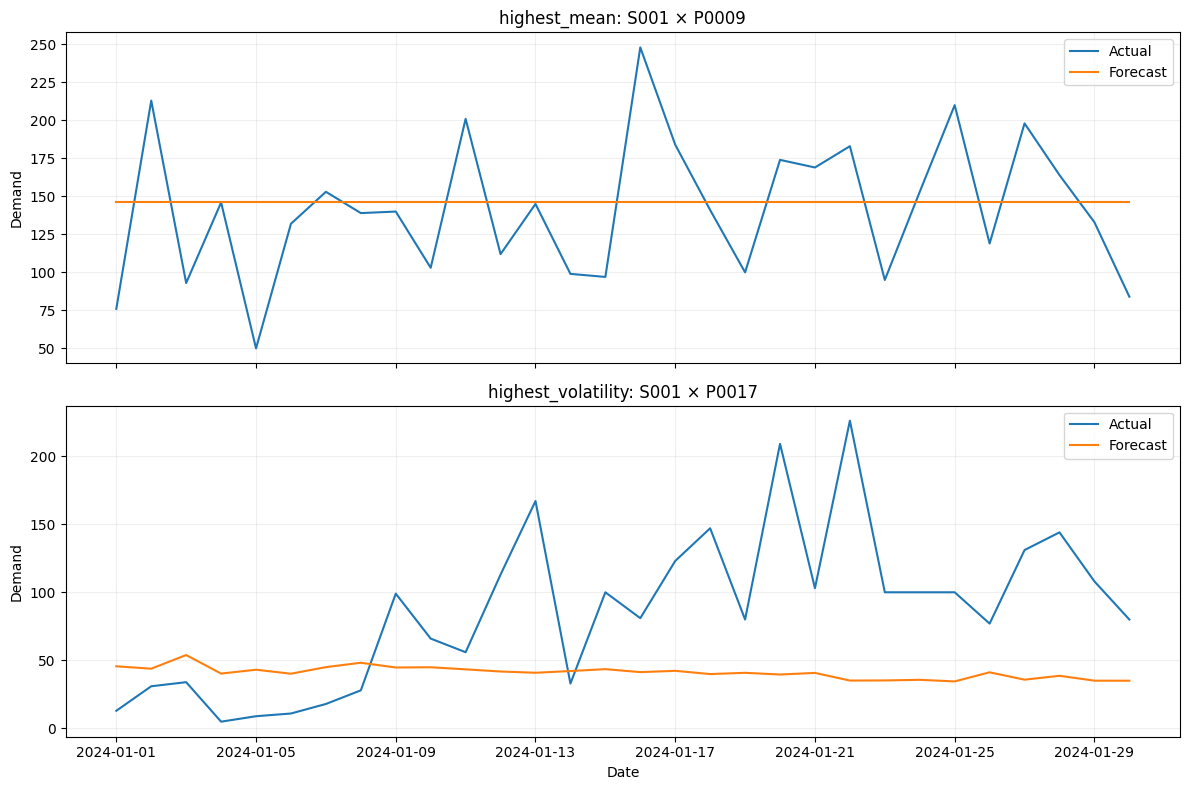

In [31]:
# Select representative series by deterministic rules for diagnostic plots
series_actual_summary = (
    final_evaluation.groupby(["Store ID", "Product ID"])
    .agg(
        Actual_Mean=("Demand", "mean"),
        Actual_Max=("Demand", "max"),
        Actual_STD=("Demand", "std"),
    )
    .reset_index()
)

representative = {
    "highest_mean": series_actual_summary.sort_values(
        ["Actual_Mean", "Store ID", "Product ID"], ascending=[False, True, True]
    ).iloc[0][["Store ID", "Product ID"]].tolist(),
    "highest_volatility": series_actual_summary.sort_values(
        ["Actual_STD", "Store ID", "Product ID"], ascending=[False, True, True]
    ).iloc[0][["Store ID", "Product ID"]].tolist(),
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, (label, (store, product)) in zip(axes, representative.items()):
    s = final_evaluation[
        (final_evaluation["Store ID"] == store)
        & (final_evaluation["Product ID"] == product)
    ].sort_values("Date")
    ax.plot(s["Date"], s["Demand"], label="Actual")
    ax.plot(s["Date"], s["Forecast_Demand"], label="Forecast")
    ax.set_title(f"{label}: {store} × {product}")
    ax.set_ylabel("Demand")
    ax.legend()
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


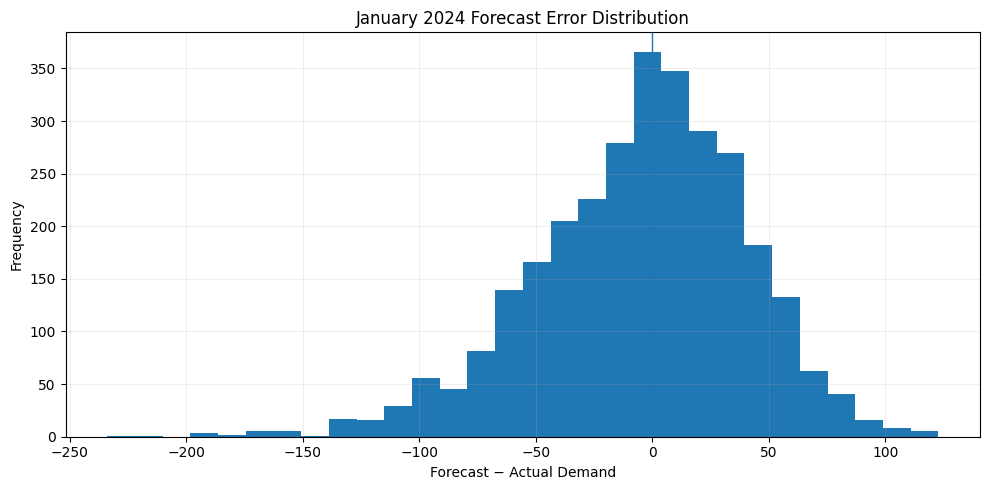

,DemandBand,Actual_Mean,Forecast_Mean,Bias,MAE,Actual_Max,Forecast_Max
0,Low,43.636968,75.194266,31.557298,36.176710,66,146.000000
1,Mid-Low,80.911609,91.792571,10.880961,27.936724,95,148.156667
2,Mid-High,109.732167,97.490119,-12.242048,25.544136,125,146.000000
3,High,158.610442,106.878804,-51.731638,51.980214,284,146.000000


In [32]:
# Error distribution and error by demand level
final_evaluation["Error"] = final_evaluation["Forecast_Demand"] - final_evaluation["Demand"]
final_evaluation["AbsError"] = final_evaluation["Error"].abs()
final_evaluation["DemandBand"] = pd.qcut(
    final_evaluation["Demand"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"],
    duplicates="drop",
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(final_evaluation["Error"], bins=30)
ax.axvline(0, linewidth=1)
ax.set_title("January 2024 Forecast Error Distribution")
ax.set_xlabel("Forecast − Actual Demand")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

error_by_band = (
    final_evaluation.groupby("DemandBand", observed=True)
    .agg(
        Actual_Mean=("Demand", "mean"),
        Forecast_Mean=("Forecast_Demand", "mean"),
        Bias=("Error", "mean"),
        MAE=("AbsError", "mean"),
        Actual_Max=("Demand", "max"),
        Forecast_Max=("Forecast_Demand", "max"),
    )
    .reset_index()
)
display(error_by_band)


## 5.15 Forecasting Conclusions

The notebook reports actual validation and final-test results rather than hard-coding claims.

Interpretation should cover:
- validation performance,
- final January performance,
- selected-model distribution,
- Store/Product/series error patterns,
- spike and range behavior,
- leakage controls,
- computational and data limitations.

No causal claim is made from observational associations, and no business impact is claimed unless it has been directly measured.


In [33]:
# Generate a concise evidence-based conclusion table
selection_distribution = (
    selected_models["Selected_Model"]
    .value_counts()
    .rename_axis("Selected_Model")
    .reset_index(name="Series_Count")
)

final_series = final_metrics[final_metrics["Level"] == "Series"].copy()

conclusion_snapshot = {
    "Validation_overall": validation_overall.sort_values(
        ["MAE", "RMSE", "sMAPE"]
    )[["Model", "MAE", "RMSE", "sMAPE"]].to_dict("records"),
    "Final_overall": overall_final_metrics,
    "Selected_model_distribution": selection_distribution.to_dict("records"),
    "Final_series_mean_MAE": float(final_series["MAE"].mean()),
    "Final_series_mean_RMSE": float(final_series["RMSE"].mean()),
    "Final_series_mean_sMAPE": float(final_series["sMAPE"].mean()),
}

pd.DataFrame({
    "Measure": [
        "Final MAE",
        "Final RMSE",
        "Final sMAPE",
        "Forecast rows",
        "Forecast series",
        "Forecast horizon days",
    ],
    "Value": [
        overall_final_metrics["MAE"],
        overall_final_metrics["RMSE"],
        overall_final_metrics["sMAPE"],
        len(final_forecast),
        final_forecast[["Store ID", "Product ID"]].drop_duplicates().shape[0],
        final_forecast["Date"].nunique(),
    ],
})


,Measure,Value
0,Final MAE,35.396478
1,Final RMSE,45.975115
2,Final sMAPE,41.199957
3,Forecast rows,3000.000000
4,Forecast series,100.000000
5,Forecast horizon days,30.000000


## 5.16 Forecast Readiness for Phase 6

Before passing forecasts to inventory optimization, verify:

- every Store × Product series has a 30-day forecast,
- forecast dates are complete,
- no duplicate forecast keys exist,
- no forecasts are missing or non-finite,
- selected models are documented,
- January actuals were not used before final evaluation,
- no historical lead time was fabricated,
- the output contains the required fields.

**Lead time:** the source data does not contain a historical lead-time field. Phase 6 must therefore treat lead time explicitly as a scenario/assumption rather than pretending it was learned from this dataset.


In [34]:
# Final readiness checks and output
expected_forecast_dates = pd.date_range(TEST_START, TEST_END, freq="D")
expected_series = forecasting_df[["Store ID", "Product ID"]].drop_duplicates()

assert set(final_forecast["Date"].unique()) == set(expected_forecast_dates)
assert final_forecast[["Store ID", "Product ID"]].drop_duplicates().merge(
    expected_series, on=["Store ID", "Product ID"], how="outer", indicator=True
)["_merge"].eq("both").all()
assert final_forecast.duplicated(
    ["Date", "Store ID", "Product ID"]
).sum() == 0
assert final_forecast["Forecast_Demand"].notna().all()
assert np.isfinite(final_forecast["Forecast_Demand"]).all()
assert final_forecast["Selected_Model"].notna().all()

final_forecast.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print("Rows:", len(final_forecast))
print("Columns:", final_forecast.columns.tolist())
print("Series:", final_forecast[["Store ID", "Product ID"]].drop_duplicates().shape[0])
print("Forecast dates:", final_forecast["Date"].min().date(), "to", final_forecast["Date"].max().date())


Saved: /content/drive/MyDrive/SupplychainManagement/final_demand_forecasts.csv
Rows: 3000
Columns: ['Date', 'Store ID', 'Product ID', 'Forecast_Demand', 'Selected_Model']
Series: 100
Forecast dates: 2024-01-01 to 2024-01-30


## Data Lineage

```text
sales_data.csv
      ↓
forecasting_df
      ↓
leakage-controlled forecasting dataset
      ↓
chronological train / validation / final test
      ↓
baseline models
      ↓
ARIMA(1,0,1)
      ↓
recursive feature-based models
      ↓
validation-based per-series model selection
      ↓
retraining through 2023-12-31
      ↓
recursive 30-day January 2024 forecasts
      ↓
final evaluation
      ↓
final_demand_forecasts.csv
      ↓
Phase 6 Inventory Optimization
```

### Remaining methodological assumptions

1. The provided Phase 5 brief is treated as the operative forecasting specification for this notebook because the supplied `PROJECT_MASTER.md` has not yet been updated from its documented Phase 1/dataset-selection status.
2. Future values of Price, Discount, Promotion, Weather Condition, Competitor Pricing, and Epidemic are not assumed to be available; therefore they are excluded from the primary forecasting model.
3. Store/Product/Category/Region are treated as static or structurally known at forecast time.
4. The primary model-selection rule is lowest validation MAE per Store × Product, with RMSE and sMAPE as tie-breakers.
5. ARIMA is fit independently by series; feature-based models are global models across all series.
6. No lead time is inferred from the source data. Phase 6 must introduce any lead-time value as an explicit scenario/assumption.
7. No model result in this notebook is considered a measured business impact.

### Execution order

Run cells **top to bottom**. The notebook is intentionally stateful only through variables created by preceding cells in this same notebook; there is no dependency on the previous Phase 5 notebook.
